# Phase 1: Exploration

Before analyzing anything, I need to understand what I'm working with. How big is the data? What does a row represent? What's missing? What can I trust?

In [1]:
import os
import duckdb
import polars as pl
from dotenv import load_dotenv

load_dotenv(override=True)
dataset_path = os.getenv("LOCAL_DATASET_PATH")
con = duckdb.connect(database=":memory:")

# Load everything as strings first - avoids DuckDB guessing types wrong on messy data
con.execute("""
    CREATE TEMP TABLE contracts AS
    SELECT * FROM read_csv_auto(
        '{0}', delim=',', header=true, strict_mode=false, all_varchar=true, parallel=false
    )
""".format(dataset_path))

## 1. How big is the dataset?

In [2]:
con.sql("SELECT COUNT(*) AS total_rows FROM contracts").pl()

total_rows
i64
1261329


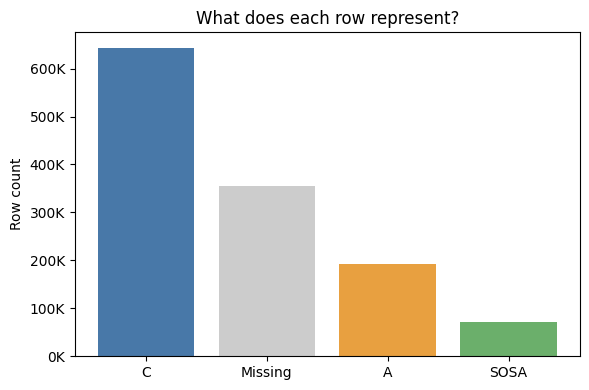

In [3]:
# Instrument type breakdown
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

inst = con.sql("""
    SELECT COALESCE(instrument_type, 'Missing') AS type, COUNT(*) AS cnt
    FROM contracts GROUP BY type ORDER BY cnt DESC
""").pl()

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'C': '#4878A8', 'Missing': '#CCCCCC', 'A': '#E8A040', 'SOSA': '#6BAF6B'}
ax.bar(inst["type"].to_list(), inst["cnt"].to_list(), 
       color=[colors.get(t, '#888') for t in inst["type"].to_list()])
ax.set_ylabel("Row count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title("What does each row represent?")
plt.tight_layout()
plt.show()

## 2. What columns do we have?

1.26M rows is a lot. Let's see what we're working with - all 43 columns loaded as VARCHAR to avoid type-guessing issues.

In [4]:
con.sql("DESCRIBE contracts").pl()

column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""reference_number""","""VARCHAR""","""YES""",null,null,null
"""procurement_id""","""VARCHAR""","""YES""",null,null,null
"""vendor_name""","""VARCHAR""","""YES""",null,null,null
"""vendor_postal_code""","""VARCHAR""","""YES""",null,null,null
"""buyer_name""","""VARCHAR""","""YES""",null,null,null
…,…,…,…,…,…
"""award_criteria""","""VARCHAR""","""YES""",null,null,null
"""socioeconomic_indicator""","""VARCHAR""","""YES""",null,null,null
"""reporting_period""","""VARCHAR""","""YES""",null,null,null


## 3. What does a single row represent?

This is the most important question to get right early. If I assume each row is a unique contract, every count and sum will be wrong.

The `instrument_type` column tells me:
- **C** = a new contract
- **A** = an amendment to an existing contract
- **SOSA** = a standing offer/supply arrangement (framework, not spending)

So one contract can appear as multiple rows. The `procurement_id` links them together.

In [5]:
# How many rows are contracts vs amendments vs standing offers?
con.sql("""
    SELECT 
        instrument_type,
        COUNT(*) AS row_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM contracts
    GROUP BY instrument_type
    ORDER BY row_count DESC
""").pl()

instrument_type,row_count,pct
str,i64,f64
"""C""",643475,51.0
null,354581,28.1
"""A""",191749,15.2
"""SOSA""",71524,5.7


In [6]:
# How many unique contracts (procurement_ids) vs total rows?
con.sql("""
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(DISTINCT procurement_id) AS unique_procurement_ids,
        COUNT(*) - COUNT(DISTINCT procurement_id) AS duplicate_rows_from_amendments
    FROM contracts
""").pl()

total_rows,unique_procurement_ids,duplicate_rows_from_amendments
i64,i64,i64
1261329,1036531,224798


## 4. How much data is missing?

With 43 columns, some are bound to have gaps. But the data dictionary tells me many fields only became mandatory after 2019 or 2022 - so older nulls are by design, not a quality problem. Let's see how bad it actually is.

In [7]:
# Null count and percentage for every column (ordered by dataset column position)
# Counts both NULL and empty string ('') as missing
total = con.sql("SELECT COUNT(*) FROM contracts").fetchone()[0]

rows = []
columns = [
    'reference_number', 'procurement_id', 'vendor_name', 'vendor_postal_code',
    'buyer_name', 'contract_date', 'economic_object_code', 'description_en',
    'description_fr', 'contract_period_start', 'delivery_date', 'contract_value',
    'original_value', 'amendment_value', 'comments_en', 'comments_fr',
    'additional_comments_en', 'additional_comments_fr', 'agreement_type_code',
    'trade_agreement', 'land_claims', 'commodity_type', 'commodity_code',
    'country_of_vendor', 'solicitation_procedure', 'limited_tendering_reason',
    'trade_agreement_exceptions', 'indigenous_business', 'indigenous_business_excluding_psib',
    'intellectual_property', 'potential_commercial_exploitation', 'former_public_servant',
    'contracting_entity', 'standing_offer_number', 'instrument_type', 'ministers_office',
    'number_of_bids', 'article_6_exceptions', 'award_criteria', 'socioeconomic_indicator',
    'reporting_period', 'owner_org', 'owner_org_title'
]

for col in columns:
    missing = con.sql(f"""
        SELECT COUNT(*) FROM contracts 
        WHERE {col} IS NULL OR TRIM({col}) = ''
    """).fetchone()[0]
    rows.append((col, missing, round(missing * 100.0 / total, 1)))

with pl.Config(tbl_rows=43):
    display(pl.DataFrame(rows, schema=["column_name", "missing_count", "missing_pct"], orient="row"))

column_name,missing_count,missing_pct
str,i64,f64
"""reference_number""",0,0.0
"""procurement_id""",13069,1.0
"""vendor_name""",78,0.0
"""vendor_postal_code""",849143,67.3
"""buyer_name""",847518,67.2
"""contract_date""",0,0.0
"""economic_object_code""",264899,21.0
"""description_en""",1026,0.1
"""description_fr""",1441,0.1


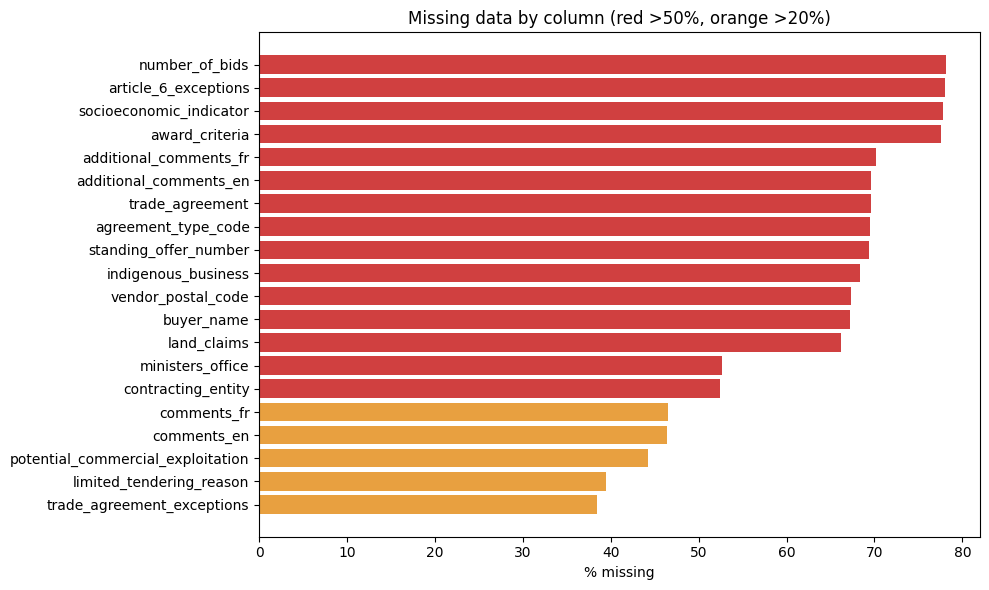

In [8]:
# Visualize missing data - top 20 most missing columns
missing_df = pl.DataFrame(rows, schema=["column_name", "missing_count", "missing_pct"], orient="row")
top_missing = missing_df.filter(pl.col("missing_pct") > 0).sort("missing_pct", descending=True).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
cols = top_missing["column_name"].to_list()
pcts = top_missing["missing_pct"].to_list()
colors_m = ['#D04040' if p > 50 else '#E8A040' if p > 20 else '#4878A8' for p in pcts]

ax.barh(cols, pcts, color=colors_m)
ax.set_xlabel("% missing")
ax.set_title("Missing data by column (red >50%, orange >20%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. What time period does the data cover?

Some of those missing fields might be concentrated in older data. Let's see when this data starts and ends. Canada's fiscal year runs April to March, and `reporting_period` uses format `YYYY-YYYY-QX`.

In [9]:
# Earliest and latest reporting periods
con.sql("""
    SELECT 
        MIN(reporting_period) AS earliest,
        MAX(reporting_period) AS latest,
        COUNT(DISTINCT reporting_period) AS distinct_quarters
    FROM contracts
""").pl()

earliest,latest,distinct_quarters
str,str,i64
"""1""","""Q4""",142


In [10]:
# Row count by fiscal year (extract the first 9 characters: "YYYY-YYYY")
con.sql("""
    SELECT 
        LEFT(reporting_period, 9) AS fiscal_year,
        COUNT(*) AS row_count
    FROM contracts
    WHERE reporting_period IS NOT NULL
    GROUP BY fiscal_year
    ORDER BY fiscal_year
""").pl()

fiscal_year,row_count
str,i64
"""1""",6
"""10""",11
"""11""",15
"""12""",15
"""2""",11
…,…
"""C-2016-20""",1
"""Q1""",162
"""Q2""",2


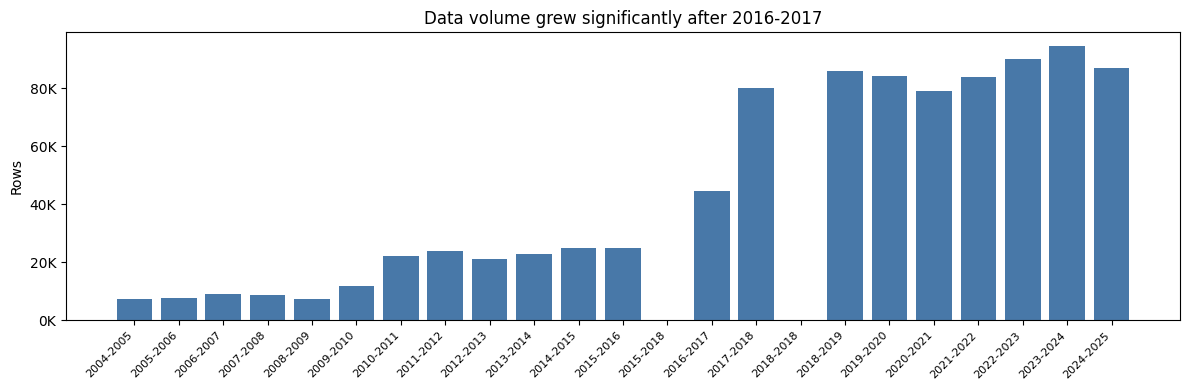

In [11]:
# Row count by fiscal year - visual
fy = con.sql("""
    SELECT LEFT(reporting_period, 9) AS fiscal_year, COUNT(*) AS row_count
    FROM contracts
    WHERE reporting_period LIKE '____-____-Q_'
      AND LEFT(reporting_period, 9) >= '2004-2005' AND LEFT(reporting_period, 9) <= '2024-2025'
    GROUP BY fiscal_year ORDER BY fiscal_year
""").pl()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(fy)), fy["row_count"].to_list(), color='#4878A8')
ax.set_xticks(range(len(fy)))
ax.set_xticklabels(fy["fiscal_year"].to_list(), rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_ylabel("Rows")
ax.set_title("Data volume grew significantly after 2016-2017")
plt.tight_layout()
plt.show()

## 6. Financial fields

Now for the money. Everything is still stored as strings, so I need to cast to numbers. Using `TRY_CAST` so bad values become NULL instead of crashing the query. First let's see how many values fail the cast, then look at the range.

In [12]:
# How many values fail to cast to a number? (data quality check)
con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(contract_value) - COUNT(TRY_CAST(contract_value AS DOUBLE)) AS contract_value_cast_failures,
        COUNT(original_value) - COUNT(TRY_CAST(original_value AS DOUBLE)) AS original_value_cast_failures,
        COUNT(amendment_value) - COUNT(TRY_CAST(amendment_value AS DOUBLE)) AS amendment_value_cast_failures
    FROM contracts
""").pl()

total_rows,contract_value_cast_failures,original_value_cast_failures,amendment_value_cast_failures
i64,i64,i64,i64
1261329,0,0,0


In [13]:
# Min, Max, Average, Median for financial fields
con.sql("""
    SELECT
        MIN(TRY_CAST(contract_value AS DOUBLE)) AS min_contract_value,
        MAX(TRY_CAST(contract_value AS DOUBLE)) AS max_contract_value,
        ROUND(AVG(TRY_CAST(contract_value AS DOUBLE)), 2) AS avg_contract_value,
        ROUND(MEDIAN(TRY_CAST(contract_value AS DOUBLE)), 2) AS median_contract_value,
        MIN(TRY_CAST(original_value AS DOUBLE)) AS min_original_value,
        MAX(TRY_CAST(original_value AS DOUBLE)) AS max_original_value,
        MIN(TRY_CAST(amendment_value AS DOUBLE)) AS min_amendment_value,
        MAX(TRY_CAST(amendment_value AS DOUBLE)) AS max_amendment_value
    FROM contracts
""").pl()

min_contract_value,max_contract_value,avg_contract_value,median_contract_value,min_original_value,max_original_value,min_amendment_value,max_amendment_value
f64,f64,f64,f64,f64,f64,f64,f64
-8.1640e6,2.0027e10,863738.01,28175.68,-120530.09,1.1219e10,-8.2477e8,2.9146e9


## 7. Key categorical fields

Good - the financial data is clean. Now let's see what *kinds* of contracts are in here. Goods vs services? Competitive vs sole-source?

In [14]:
# Commodity type: Goods vs Services vs Construction
con.sql("""
    SELECT 
        commodity_type,
        COUNT(*) AS row_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM contracts
    GROUP BY commodity_type
    ORDER BY row_count DESC
""").pl()

commodity_type,row_count,pct
str,i64,f64
"""S""",480390,38.1
null,448881,35.6
"""G""",266118,21.1
"""C""",65940,5.2


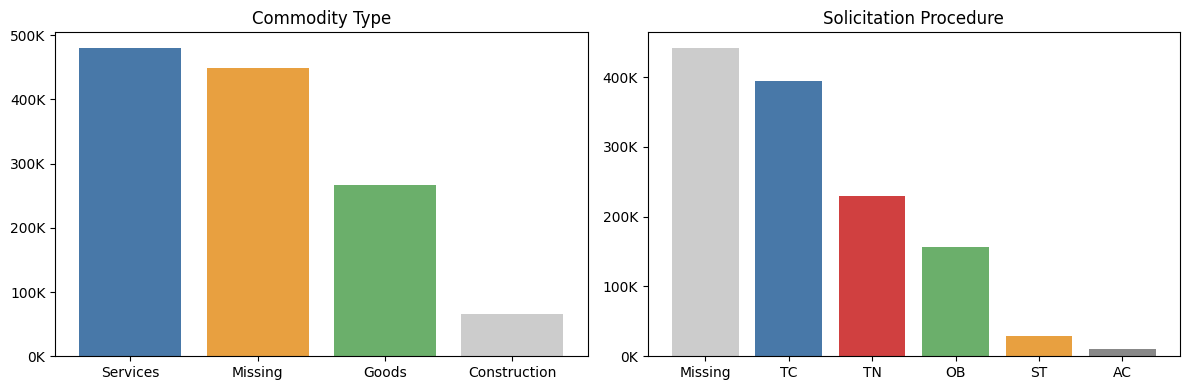

In [15]:
# Commodity type and solicitation procedure side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Commodity type
comm = con.sql("""
    SELECT CASE commodity_type WHEN 'S' THEN 'Services' WHEN 'G' THEN 'Goods' WHEN 'C' THEN 'Construction' ELSE 'Missing' END AS type,
        COUNT(*) AS cnt
    FROM contracts GROUP BY type ORDER BY cnt DESC
""").pl()
axes[0].bar(comm["type"].to_list(), comm["cnt"].to_list(), color=['#4878A8','#E8A040','#6BAF6B','#CCCCCC'])
axes[0].set_title("Commodity Type")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Solicitation procedure
sol = con.sql("""
    SELECT COALESCE(solicitation_procedure, 'Missing') AS proc, COUNT(*) AS cnt
    FROM contracts GROUP BY proc ORDER BY cnt DESC
""").pl()
axes[1].bar(sol["proc"].to_list(), sol["cnt"].to_list(), color=['#CCCCCC','#4878A8','#D04040','#6BAF6B','#E8A040','#888888'])
axes[1].set_title("Solicitation Procedure")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

In [16]:
# Solicitation procedure: How competitive is government procurement?
con.sql("""
    SELECT 
        solicitation_procedure,
        CASE solicitation_procedure
            WHEN 'OB' THEN 'Open Bidding (GETS)'
            WHEN 'TC' THEN 'Traditional Competitive'
            WHEN 'TN' THEN 'Non-Competitive'
            WHEN 'AC' THEN 'Advance Contract Award Notice'
            WHEN 'ST' THEN 'Selective Tendering'
            ELSE 'Unknown / NULL'
        END AS description,
        COUNT(*) AS row_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM contracts
    GROUP BY solicitation_procedure
    ORDER BY row_count DESC
""").pl()

solicitation_procedure,description,row_count,pct
str,str,i64,f64
null,"""Unknown / NULL""",441948,35.0
"""TC""","""Traditional Competitive""",393882,31.2
"""TN""","""Non-Competitive""",229393,18.2
"""OB""","""Open Bidding (GETS)""",157133,12.5
"""ST""","""Selective Tendering""",28559,2.3
"""AC""","""Advance Contract Award Notice""",10414,0.8


In [17]:
# Country of vendor: How much goes to Canadian vs international vendors?
con.sql("""
    SELECT 
        country_of_vendor,
        COUNT(*) AS row_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM contracts
    WHERE country_of_vendor IS NOT NULL
    GROUP BY country_of_vendor
    ORDER BY row_count DESC
    LIMIT 15
""").pl()

country_of_vendor,row_count,pct
str,i64,f64
"""CA""",788786,93.7
"""US""",26888,3.2
"""GB""",4146,0.5
"""DE""",1890,0.2
"""FR""",1472,0.2
…,…,…
"""AU""",536,0.1
"""NL""",514,0.1
"""PL""",508,0.1


## 8. Top departments and vendors

Now that I know the shape of the data, who are the biggest players?

In [18]:
# Top 15 departments by number of contract rows
con.sql("""
    SELECT 
        SPLIT_PART(owner_org_title, ' | ', 1) AS department,
        COUNT(*) AS row_count,
        COUNT(DISTINCT procurement_id) AS unique_contracts
    FROM contracts
    GROUP BY owner_org_title
    ORDER BY row_count DESC
    LIMIT 15
""").pl()

department,row_count,unique_contracts
str,i64,i64
"""National Defence""",343750,292588
"""Fisheries and Oceans Canada""",115126,96550
"""Global Affairs Canada""",76729,66923
"""Public Services and Procuremen…",68998,49516
"""Environment and Climate Change…",68083,60504
…,…,…
"""Royal Canadian Mounted Police""",34872,29269
"""Natural Resources Canada""",31086,27683
"""Shared Services Canada""",27949,21782


In [19]:
# Top 15 vendors by number of contracts (original contracts only, not amendments)
con.sql("""
    SELECT 
        vendor_name,
        COUNT(*) AS contract_count,
        ROUND(SUM(TRY_CAST(contract_value AS DOUBLE)), 2) AS total_value
    FROM contracts
    WHERE instrument_type = 'C'
      AND vendor_name IS NOT NULL
    GROUP BY vendor_name
    ORDER BY contract_count DESC
    LIMIT 15
""").pl()

vendor_name,contract_count,total_value
str,i64,f64
"""MCKESSON CANADA CORPORATION""",5944,3.2139e8
"""CANADIAN CORPS OF COMMISSIONAI…",2839,8.4603e8
"""NISHA TECHNOLOGIES INC.""",1859,1.8603e8
"""TEKNION LIMITED""",1584,1.1589e8
"""IRVING OIL COMMERCIAL G.P.""",1554,2.5276e8
…,…,…
"""WARTSILA CANADA INC""",1061,1.0890e8
"""MOTOROLA SOLUTIONS CANADA INC""",1020,3.6693e8
"""MICROSOFT CANADA INC.""",983,1.5745e9


In [20]:
# Top 15 vendors by total dollar value (original contracts only)
con.sql("""
    SELECT 
        vendor_name,
        COUNT(*) AS contract_count,
        ROUND(SUM(TRY_CAST(contract_value AS DOUBLE)), 2) AS total_value
    FROM contracts
    WHERE instrument_type = 'C'
      AND vendor_name IS NOT NULL
    GROUP BY vendor_name
    ORDER BY total_value DESC
    LIMIT 15
""").pl()

vendor_name,contract_count,total_value
str,i64,f64
"""SkyAlyne Canada Limited Partne…",1,1.1219e10
"""Irving Shipbuilding Inc.""",1,8.0103e9
"""VANCOUVER SHIPYARDS CO LTD""",38,5.0416e9
"""Lockheed Martin Corporation""",1,4.8082e9
"""CAE Military Aviation Training…",1,4.4822e9
…,…,…
"""IBM CANADA LTD.""",606,3.0560e9
"""Airbus Defense & Space SA""",1,2.7480e9
"""BGIS GLOBAL INTEGRATED SOLUTIO…",1,2.6420e9


## 9. Sample rows

Stats give me the big picture, but I want to see actual rows to spot things numbers miss - weird formatting, bilingual patterns, how amendments relate to their parent contract.

In [21]:
# A contract with its amendment(s) — see how procurement_id links them
con.sql("""
    SELECT 
        procurement_id, instrument_type, vendor_name,
        contract_value, original_value, amendment_value,
        contract_date, reporting_period
    FROM contracts
    WHERE procurement_id IN (
        SELECT procurement_id 
        FROM contracts 
        WHERE procurement_id IS NOT NULL
        GROUP BY procurement_id 
        HAVING COUNT(*) >= 3
        LIMIT 1
    )
    ORDER BY reporting_period
""").pl()

procurement_id,instrument_type,vendor_name,contract_value,original_value,amendment_value,contract_date,reporting_period
str,str,str,str,str,str,str,str
"""P2200012""","""C""","""1101417 ONTARIO INC""","""33900.0""","""33900.0""","""0.0""","""2021-02-03""","""2020-2021-Q4"""
"""P2200012""","""C""","""Bell Canada ( Telephone- North…","""89000""","""89000""","""0""","""2021-04-07""","""2021-2022-Q1"""
"""P2200012""","""C""","""Betty Dion Enterprises Limited""","""24144.75""","""24144.75""","""0""","""2021-09-01""","""2021-2022-Q2"""
"""P2200012""","""A""","""SINCLAIR, JOHN""","""17185.75""","""9848.75""","""7337.0""","""2021-04-06""","""2021-2022-Q3"""
"""P2200012""","""A""","""Betty Dion Enterprises Limited""","""40241.25""","""24144.75""","""16096.5""","""2021-09-01""","""2021-2022-Q4"""


## Takeaways

- **1.26M rows, 43 columns**, spanning mid-2000s to 2025
- **Each row is a transaction**, not a unique contract - must filter by `instrument_type`
- **28% of rows have no instrument_type** - these are older records before the field was mandatory
- **Missing data follows a pattern** - fields became mandatory in phases (2019, 2022), so older data has predictable gaps
- **Financial fields cast cleanly** - zero cast failures, but values range from negative to $20B (heavily skewed)
- **354K rows with no instrument_type and 275K with no reporting_period** - these need to be filtered out for any time-based or type-based analysis

Moving to Phase 2: profiling key fields and looking for patterns worth investigating.